# Script to prepare raw position and value CVS files

__Note:__ If merging multiple datasets with different origin set (typically done to increase the resolution of the total mapping area using the same xyz box size but measure points offset by manipulating the origin), the original/correct/same origin should be used for all datasets - independent of origin listed in filename.

__Note:__ If the dataset contains unwanted data (typically when starting a run/after a run), these rows shouldn't be removed from the original files, but only after positions and values have been merged and remapped into a combinded file. This will minimise the chance of cutting too many rows in the head/trail of the file(s).

In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1613687434850_size_90-64-23_feed_600_origin_535-320-230.csv
#1613732400294_size_90-64-23_feed_600_origin_535-320-230.csv
#1613818800565_size_90-64-23_feed_600_origin_535-320-230.csv
#1613845968074_size_90-64-23_feed_600_origin_535-325-230.csv
#1613862000111_size_90-64-23_feed_600_origin_535-325-230.csv
#1613905200417_size_90-64-23_feed_600_origin_535-325-230.csv
#1613948400604_size_90-64-23_feed_600_origin_535-325-230.csv
#1613991600588_size_90-64-23_feed_600_origin_535-325-230.csv NO MOVEMENT - CAN BE SKIPPED
#1614000450222_size_90-64-22_feed_600_origin_535-320-235.csv
#1614034800237_size_90-64-22_feed_600_origin_535-320-235.csv
#1614078000516_size_90-64-22_feed_600_origin_535-320-235.csv
#1614121200586_size_90-64-22_feed_600_origin_535-320-235.csv
#1614164400593_size_90-64-22_feed_600_origin_535-320-235.csv
#1614207600576_size_90-64-22_feed_600_origin_535-320-235.csv
#1614250800589_size_90-64-22_feed_600_origin_535-320-235.csv

posX = 0
posY = 0
posZ = 0

width = 900
hWidth = int(width/2)
depth = 64
hDepth = int(depth/2)
height = 230

filename = '1613818800565_size_90-64-23_feed_600_origin_535-320-230.csv'

df_val = pd.read_csv('CSV_files/values-' + filename, names=['A', 'B', 'C', 'Z', 'valTimestamp'])
df_pos = pd.read_csv('CSV_files/position-' + filename, names=['posX', 'posY', 'posZ', 'posTimestamp'])

df_val = df_val[['valTimestamp', 'A', 'B', 'C', 'Z']]
df_pos = df_pos[['posTimestamp', 'posX', 'posY', 'posZ']]
df_pos.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)

# Shifting xyz positions to remap origin from home position of the rig to the top of the primary side
df_pos["posX"] -= 535
df_pos["posY"] -= 320
df_pos["posZ"] += 230

df_pos = df_pos.round(decimals=2)

#df_val
#df_pos

posXInterp = np.interp(df_val['valTimestamp'], df_pos['posTimestamp'], df_pos['posX'])
posYInterp = np.interp(df_val['valTimestamp'], df_pos['posTimestamp'], df_pos['posY'])
posZInterp = np.interp(df_val['valTimestamp'], df_pos['posTimestamp'], df_pos['posZ'])
df_combined = df_val
df_combined['posX'] = pd.DataFrame(posXInterp, columns = ['posXInterp'])
df_combined['posY'] = pd.DataFrame(posYInterp, columns = ['posYInterp'])
df_combined['posZ'] = pd.DataFrame(posZInterp, columns = ['posZInterp'])
df_combined = df_combined.round(decimals=2)
df_combined.drop(['valTimestamp'], axis=1)
df_combined = df_combined.loc[(df_combined['posX'] >= -hWidth) & (df_combined['posX'] <= hWidth)]
#df_combined.rename(columns={"valTimestamp": "Timestamp"}, inplace=True)
df_combined = df_combined[['posX', 'posY', 'posZ', 'A', 'B', 'C', 'Z']]

df_combined.to_csv('CSV_combined/combined-' + filename, header=False, index=False)
print('Saved file: CSV_combined/combined-' + filename)

Saved file: CSV_combined/combined-1613818800565_size_90-64-23_feed_600_origin_535-320-230.csv


,posX,posY,posZ,A,B,C,Z
0,-32.78,-280.0,220.0,3788,568,1110,21
1,-30.85,-280.0,220.0,3772,586,1136,21
2,-28.62,-280.0,220.0,3764,588,1124,21
3,-26.51,-280.0,220.0,3774,578,1148,22
4,-24.53,-280.0,220.0,3726,570,1138,22
...,...,...,...,...,...,...,...
126089,-450.00,-310.0,230.0,1012,438,286,13
126090,-450.00,-310.0,230.0,984,416,298,13
126091,-450.00,-310.0,230.0,992,420,296,12
126092,-450.00,-310.0,230.0,1014,438,302,12


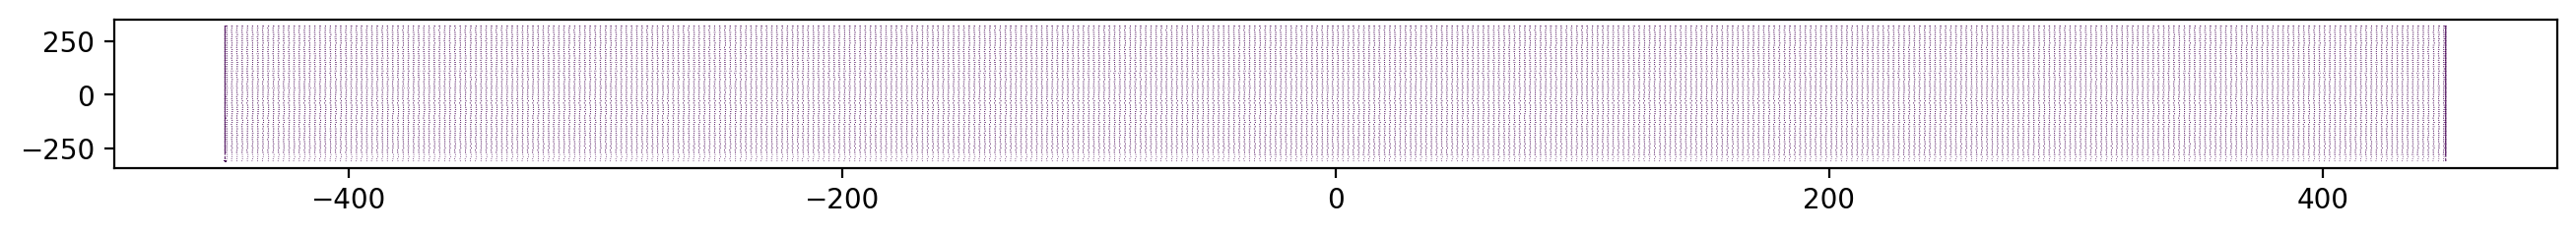

In [116]:
plt.figure(figsize=(16, 1), dpi=(200))
plt.scatter(df_combined['posX'], df_combined['posY'], c=df_combined['Z'], s=0.1, edgecolors='none', cmap = 'viridis', vmin=0, vmax=35000)
plt.savefig('combined.png', dpi=2400)

df_combined

,posX,posY,posZ,A,B,C,Z
56673,-449.1,-315.0,20.0,696,348,310,12
56674,-447.2,-315.0,20.0,692,340,304,12
56675,-444.9,-315.0,20.0,734,334,326,12
56676,-442.9,-315.0,20.0,694,340,316,12
56677,-440.8,-315.0,20.0,750,348,314,12
...,...,...,...,...,...,...,...
76141,240.7,125.0,20.0,450,561,8031,13
76142,242.8,125.0,20.0,423,533,7912,13
76143,244.9,125.0,20.0,441,515,7718,13
76144,247.0,125.0,20.0,414,552,7617,13


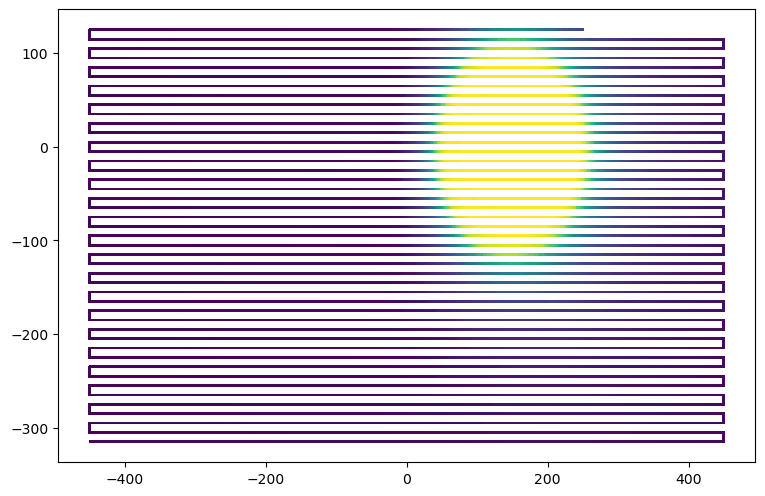

In [98]:
df_sliceZ = df_combined.loc[(df_combined['posZ'] == posZ)]
df_sliceZ = df_sliceZ.round(decimals=1)
df_sliceZ.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)
    
plt.figure(figsize=(9, 6), dpi=(100))
plt.scatter(df_sliceZ['posX'], df_sliceZ['posY'], c=df_sliceZ['C'], marker='s', s=4, edgecolors='none', cmap = 'viridis', vmin=0, vmax=35000)
plt.savefig('sliceZ.png', dpi=200)

df_sliceZ

,posX,posY,posZ,A,B,C,Z
18393,-449.3,105.0,0.0,446,636,346,12
18394,-447.2,105.0,0.0,436,636,322,12
18395,-445.2,105.0,0.0,440,678,320,12
18396,-443.2,105.0,0.0,456,640,342,12
18397,-440.9,105.0,0.0,470,710,326,12
...,...,...,...,...,...,...,...
75367,442.7,105.0,20.0,328,380,1500,13
75368,445.0,105.0,20.0,330,396,1488,12
75369,447.0,105.0,20.0,340,390,1466,12
75370,449.0,105.0,20.0,328,382,1446,12


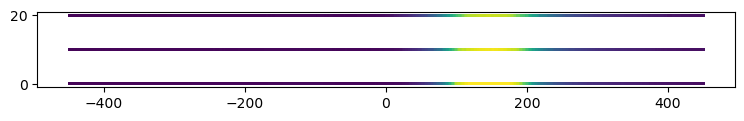

In [100]:
df_sliceY = df_combined.loc[(df_combined['posY'] == posY)]
df_sliceY = df_sliceY.round(decimals=1)
df_sliceY.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)
    
plt.figure(figsize=(9, 1), dpi=(100))
plt.scatter(df_sliceY['posX'], df_sliceY['posZ'], c=df_sliceY['C'], marker='s', s=4, edgecolors='none', cmap = 'viridis', vmin=0, vmax=35000)
plt.savefig('sliceY.png', dpi=200)

df_sliceY

,posX,posY,posZ,A,B,C,Z
122,-450.0,-315.0,0.0,652,286,248,12
123,-449.2,-315.0,0.0,636,292,262,13
124,-446.9,-315.0,0.0,670,294,260,12
125,-445.0,-315.0,0.0,650,282,262,13
126,-442.8,-315.0,0.0,646,294,254,12
...,...,...,...,...,...,...,...
76141,240.7,125.0,20.0,450,561,8031,13
76142,242.8,125.0,20.0,423,533,7912,13
76143,244.9,125.0,20.0,441,515,7718,13
76144,247.0,125.0,20.0,414,552,7617,13


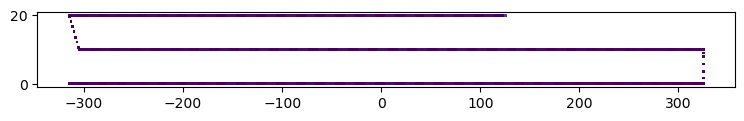

In [111]:
df_sliceX = df_combined
df_sliceX = df_sliceX.round(decimals=1)
df_sliceX.drop_duplicates(subset=['posX', 'posY', 'posZ'], keep='last',inplace=True)
    
plt.figure(figsize=(9, 1), dpi=(100))
plt.scatter(df_sliceX['posY'], df_sliceX['posZ'], c=df_sliceX['C'], marker='s', s=4, edgecolors='none', cmap = 'viridis', vmin=0, vmax=35000)
plt.savefig('sliceX.png', dpi=200)

df_sliceX